Confusion Matrix:
 [[1696    0]
 [  60    1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1696
           1       1.00      0.02      0.03        61

    accuracy                           0.97      1757
   macro avg       0.98      0.51      0.51      1757
weighted avg       0.97      0.97      0.95      1757



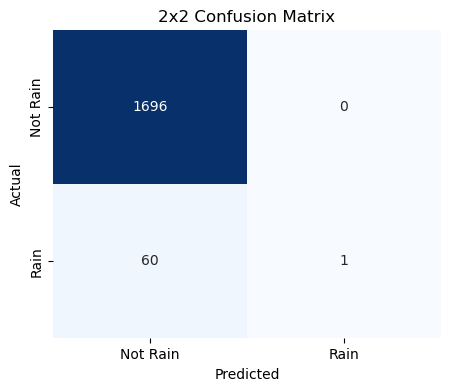

In [2]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("Weather_Dataset.csv")   # adjust name if needed

# -------------------------------
# 1. Drop non-numeric/unnecessary columns
# -------------------------------
if "Date" in data.columns:
    data = data.drop("Date", axis=1)   # drop datetime column

# -------------------------------
# 2. Separate features and target
# -------------------------------
X = data.drop("Weather", axis=1)   # assuming target column = Weather
y = data["Weather"]

# -------------------------------
# 3. Binary target (Rain vs Not Rain)
# -------------------------------
y = y.apply(lambda x: 1 if x == "Rain" else 0)

# -------------------------------
# 4. Encode categorical features (get_dummies)
# -------------------------------
X = pd.get_dummies(X)

# -------------------------------
# 5. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------------
# 6. Train model
# -------------------------------
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 7. Predictions
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 8. Confusion matrix (2x2)
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------------
# 9. Plot confusion matrix
# -------------------------------
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Rain", "Rain"],
            yticklabels=["Not Rain", "Rain"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("2x2 Confusion Matrix")
plt.show()
